In [1]:
import numpy as np
from scipy.stats import norm


class GaussianMixture1D:
    def __init__(self, weights, means, stds):
        self.weights = np.asarray(weights, dtype=float)
        self.means = np.asarray(means, dtype=float)
        self.stds = np.asarray(stds, dtype=float)

        if not (len(self.weights) == len(self.means) == len(self.stds)):
            raise ValueError("weights, means, and stds must have the same length")

        if np.any(self.stds <= 0):
            raise ValueError("All standard deviations must be positive")

        if np.any(self.weights < 0):
            raise ValueError("All weights must be non-negative")

        weight_sum = self.weights.sum()
        if not np.isclose(weight_sum, 1.0):
            self.weights = self.weights / weight_sum  # normalize automatically

    def pdf(self, x):
        """
        Probability density function of the Gaussian mixture.
        x can be a scalar or a NumPy array.
        """
        x = np.asarray(x, dtype=float)

        # Shape: (n_points, n_components)
        component_pdfs = norm.pdf(
            x[..., np.newaxis],
            loc=self.means,
            scale=self.stds
        )

        return np.sum(self.weights * component_pdfs, axis=-1)

    def cdf(self, x):
        """
        Cumulative distribution function of the Gaussian mixture.
        x can be a scalar or a NumPy array.
        """
        x = np.asarray(x, dtype=float)

        # Shape: (n_points, n_components)
        component_cdfs = norm.cdf(
            x[..., np.newaxis],
            loc=self.means,
            scale=self.stds
        )

        return np.sum(self.weights * component_cdfs, axis=-1)

PDF at x=0: 0.031536126683237055
CDF at x=0: 0.40868238898362136


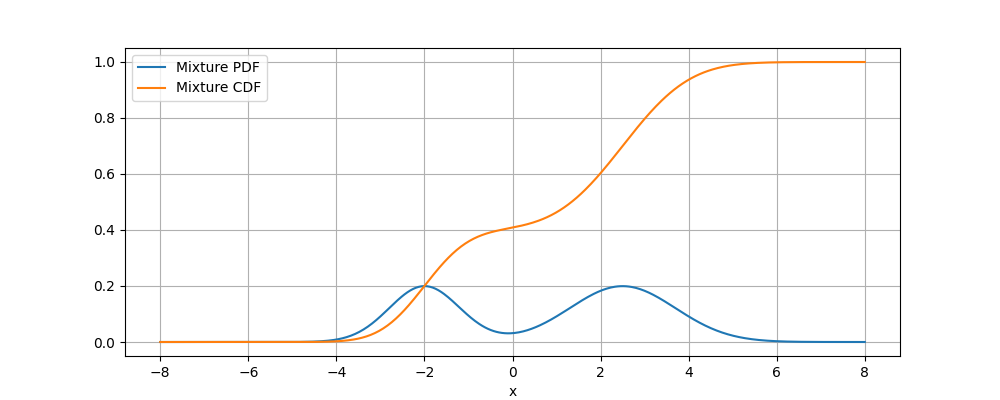

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

# Example: bimodal Gaussian mixture
weights = [0.4, 0.6]
means = [-2.0, 2.5]
stds = [0.8, 1.2]

gmm = GaussianMixture1D(weights, means, stds)

x = np.linspace(-8, 8, 500)
pdf_vals = gmm.pdf(x)
cdf_vals = gmm.cdf(x)

print("PDF at x=0:", gmm.pdf(0.0))
print("CDF at x=0:", gmm.cdf(0.0))

plt.figure(figsize=(10, 4))
plt.plot(x, pdf_vals, label="Mixture PDF")
plt.plot(x, cdf_vals, label="Mixture CDF")
plt.legend()
plt.xlabel("x")
plt.grid(True)
plt.show()

In [3]:
import numpy as np
from scipy.stats import norm

def gaussian_mixture_pdf(x, weights, means, stds):
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)
    means = np.asarray(means, dtype=float)
    stds = np.asarray(stds, dtype=float)

    weights = weights / weights.sum()
    return np.sum(
        weights * norm.pdf(x[..., None], loc=means, scale=stds),
        axis=-1
    )

def gaussian_mixture_cdf(x, weights, means, stds):
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)
    means = np.asarray(means, dtype=float)
    stds = np.asarray(stds, dtype=float)

    weights = weights / weights.sum()
    return np.sum(
        weights * norm.cdf(x[..., None], loc=means, scale=stds),
        axis=-1
    )

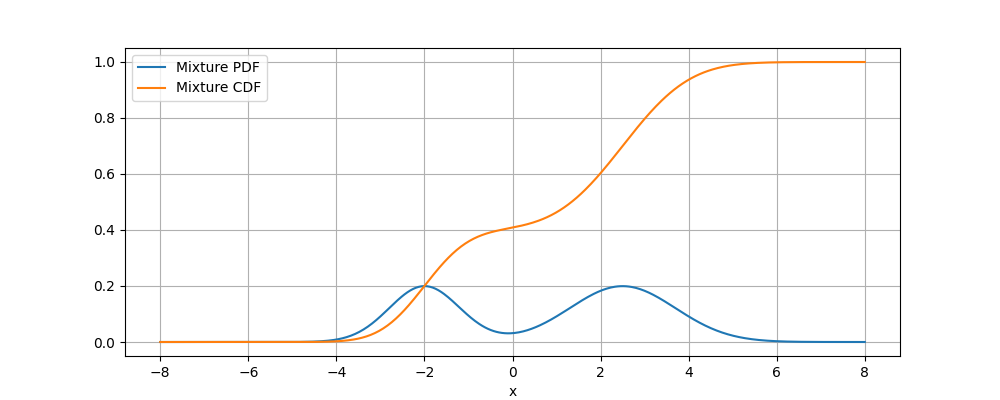

In [6]:
# Example: bimodal Gaussian mixture
weights = [0.4, 0.6]
means = [-2.0, 2.5]
stds = [0.8, 1.2]

x = np.linspace(-8, 8, 500)

pdf_vals2 = gaussian_mixture_pdf(x, weights, means, stds)
cdf_vals2 = gaussian_mixture_cdf(x, weights, means, stds)

plt.figure(figsize=(10, 4))
plt.plot(x, pdf_vals2, label="Mixture PDF")
plt.plot(x, cdf_vals2, label="Mixture CDF")
plt.legend()
plt.xlabel("x")
plt.grid(True)
plt.show()


In [ ]:
val = np.random.uniform()